Train: 700  Validation: 150  Internal test: 150
ridge      deg 1:  R2 train 0.1267 | val 0.1155 | test 0.1238   RMSE val 3.2424  (0s)
ridge      deg 2:  R2 train 0.7310 | val 0.6858 | test 0.6436   RMSE val 1.9325  (0s)
ridge      deg 3:  R2 train 0.9247 | val 0.8992 | test 0.8492   RMSE val 1.0944  (0s)
ridge      deg 4:  R2 train 0.9644 | val 0.9319 | test 0.9067   RMSE val 0.8997  (0s)
ridge      deg 5:  R2 train 0.9791 | val 0.9499 | test 0.9388   RMSE val 0.7720  (0s)
ridge      deg 6:  R2 train 0.9846 | val 0.9560 | test 0.9344   RMSE val 0.7229  (1s)
ridge      deg 7:  R2 train 0.9796 | val 0.9482 | test 0.9310   RMSE val 0.7845  (1s)
lasso      deg 1:  R2 train 0.1271 | val 0.1168 | test 0.1232   RMSE val 3.2399  (0s)
lasso      deg 2:  R2 train 0.7312 | val 0.6861 | test 0.6423   RMSE val 1.9315  (0s)
lasso      deg 3:  R2 train 0.9225 | val 0.9015 | test 0.8604   RMSE val 1.0818  (0s)
lasso      deg 4:  R2 train 0.9582 | val 0.9436 | test 0.9279   RMSE val 0.8188  (0s)
lasso 

,model,degree,train_rmse,val_rmse,test_rmse,train_r2,val_r2,test_r2
0,ridge,1,2.9505,3.2424,2.7621,0.1267,0.1155,0.1238
1,ridge,2,1.6375,1.9325,1.7616,0.7310,0.6858,0.6436
2,ridge,3,0.8662,1.0944,1.1460,0.9247,0.8992,0.8492
3,ridge,4,0.5957,0.8997,0.9013,0.9644,0.9319,0.9067
4,ridge,5,0.4567,0.7720,0.7299,0.9791,0.9499,0.9388
5,ridge,6,0.3916,0.7229,0.7556,0.9846,0.9560,0.9344
6,ridge,7,0.4506,0.7845,0.7754,0.9796,0.9482,0.9310
7,lasso,1,2.9500,3.2399,2.7630,0.1271,0.1168,0.1232
8,lasso,2,1.6369,1.9315,1.7648,0.7312,0.6861,0.6423
9,lasso,3,0.8787,1.0818,1.1026,0.9225,0.9015,0.8604



Validation R^2  (rows = degree, columns = model):


model,elasticnet,lasso,ridge
degree,,,
1,0.1156,0.1168,0.1155
2,0.6861,0.6861,0.6858
3,0.9013,0.9015,0.8992
4,0.9421,0.9436,0.9319
5,0.9706,0.9711,0.9499
6,0.9695,0.9702,0.9560
7,0.9699,0.9703,0.9482



Internal-test R^2  (rows = degree, columns = model):


model,elasticnet,lasso,ridge
degree,,,
1,0.1243,0.1232,0.1238
2,0.6427,0.6423,0.6436
3,0.8591,0.8604,0.8492
4,0.9265,0.9279,0.9067
5,0.9629,0.9637,0.9388
6,0.9627,0.9631,0.9344
7,0.9624,0.9626,0.9310



Train R^2  (rows = degree, columns = model):


model,elasticnet,lasso,ridge
degree,,,
1,0.1268,0.1271,0.1267
2,0.7312,0.7312,0.7310
3,0.9229,0.9225,0.9247
4,0.9580,0.9582,0.9644
5,0.9783,0.9777,0.9791
6,0.9780,0.9795,0.9846
7,0.9806,0.9797,0.9796



Validation RMSE  (rows = degree, columns = model):


model,elasticnet,lasso,ridge
degree,,,
1,3.2421,3.2399,3.2424
2,1.9316,1.9315,1.9325
3,1.0829,1.0818,1.0944
4,0.8297,0.8188,0.8997
5,0.5909,0.5864,0.7720
6,0.6022,0.5952,0.7229
7,0.5982,0.5937,0.7845


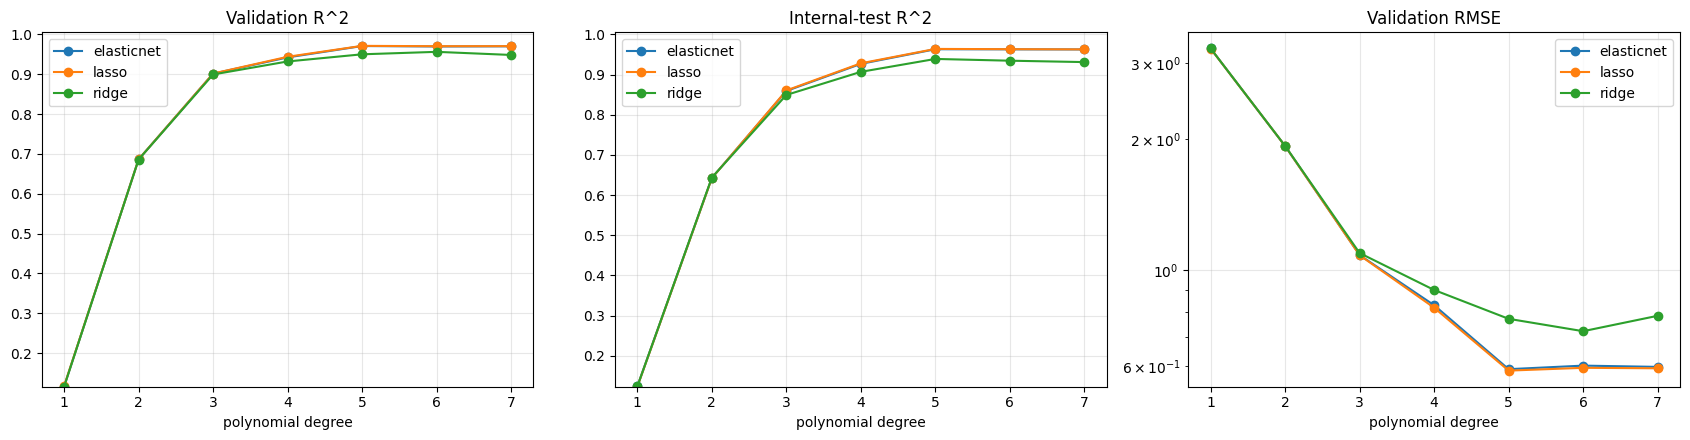


=== Final comparison (best degree for each model, refit on train+validation) ===


,best_degree,val_rmse,val_r2,test_rmse,test_mae,test_r2
model,,,,,,
ridge,6,0.7229,0.9560,0.7583,0.5929,0.9340
lasso,5,0.5864,0.9711,0.5682,0.4592,0.9629
elasticnet,5,0.5909,0.9706,0.5761,0.4651,0.9619


Baseline RMSE (always predict the mean): 2.9508   (R^2 = 0 by definition)

>>> BEST: lasso, degree 5   (internal test RMSE 0.5682, R^2 0.9629)


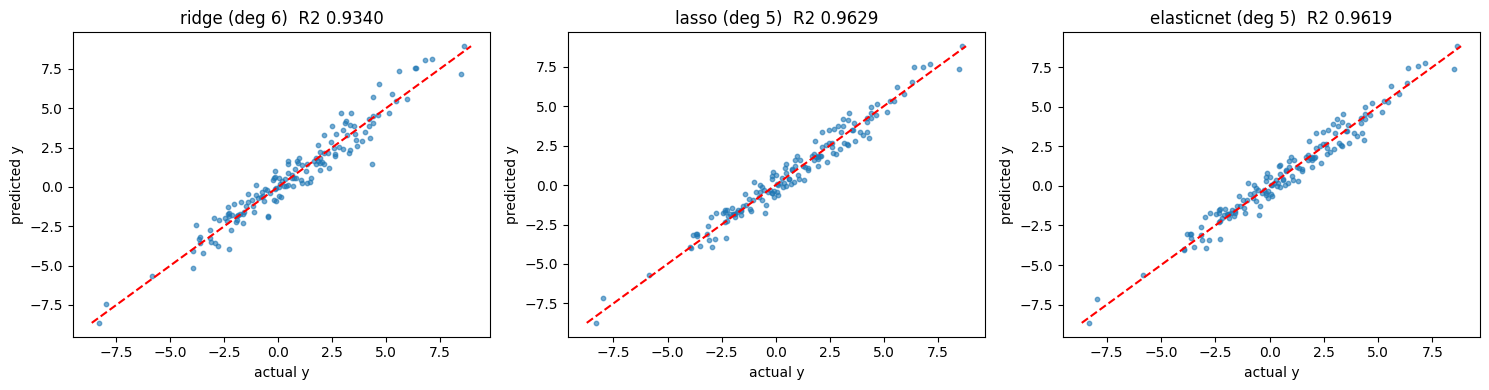


Test prediction range: -10.25 to 17.43
Train y range        : -10.11 to 14.12
Saved IMT2024091_pred_var1.csv (1000, 1)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# Compare Ridge vs Lasso vs ElasticNet (polynomial features)
# Reports RMSE and R^2 for EVERY model at EVERY degree.
# Split of the TRAIN file:  70% train | 15% validation | 15% internal test
# The external test file is only used at the very end for predictions.
# ============================================================
import os, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LassoCV, RidgeCV, ElasticNetCV
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200)
SEED = 42
np.random.seed(SEED)

# ------------------------------------------------------------
# 1. LOAD DATA
# ------------------------------------------------------------
TRAIN_FILE = "IMT2024091_train_var1.csv"
TEST_FILE  = "IMT2024091_test_var1.csv"

if not (os.path.exists(TRAIN_FILE) and os.path.exists(TEST_FILE)):
    from google.colab import files
    files.upload()

train = pd.read_csv(TRAIN_FILE)
test  = pd.read_csv(TEST_FILE)          # no labels, only for final prediction
FEATURES = ["x1", "x2", "x3", "x4", "x5", "x6"]

X, y = train[FEATURES].values, train["y"].values
X_ext = test[FEATURES].values

# ------------------------------------------------------------
# 2. SPLIT THE TRAIN FILE: train / validation / internal test
# ------------------------------------------------------------
X_dev, X_te, y_dev, y_te = train_test_split(X, y, test_size=0.15, random_state=SEED)
X_tr, X_val, y_tr, y_val = train_test_split(X_dev, y_dev, test_size=0.15/0.85, random_state=SEED)
print(f"Train: {len(X_tr)}  Validation: {len(X_val)}  Internal test: {len(X_te)}")

def rmse(a, b):
    return float(np.sqrt(np.mean((np.asarray(a) - np.asarray(b)) ** 2)))

# ------------------------------------------------------------
# 3. THE MODELS
# ------------------------------------------------------------
def make_model(degree, kind):
    if kind == "ridge":
        reg = RidgeCV(alphas=np.logspace(-3, 3, 13))
    elif kind == "lasso":
        reg = LassoCV(cv=3, n_alphas=40, max_iter=50000, tol=1e-3, random_state=SEED)
    else:  # elasticnet = mix of L1 and L2
        reg = ElasticNetCV(l1_ratio=[0.3, 0.7], cv=3, n_alphas=30, max_iter=50000, tol=1e-3, random_state=SEED)
    return make_pipeline(PolynomialFeatures(degree, include_bias=False), StandardScaler(), reg)

KINDS   = ["ridge", "lasso", "elasticnet"]
DEGREES = range(1, 8)

# ------------------------------------------------------------
# 4. FIT ON TRAIN; RECORD RMSE + R^2 ON TRAIN, VALIDATION AND INTERNAL TEST
#    (the model is selected using VALIDATION only; the test columns are for information)
# ------------------------------------------------------------
rows = []
for kind in KINDS:
    for degree in DEGREES:
        t0 = time.time()
        m = make_model(degree, kind).fit(X_tr, y_tr)
        p_tr, p_val, p_te = m.predict(X_tr), m.predict(X_val), m.predict(X_te)
        rows.append(dict(model=kind, degree=degree,
                         train_rmse=rmse(y_tr, p_tr),  val_rmse=rmse(y_val, p_val),  test_rmse=rmse(y_te, p_te),
                         train_r2=r2_score(y_tr, p_tr), val_r2=r2_score(y_val, p_val), test_r2=r2_score(y_te, p_te)))
        r = rows[-1]
        print(f"{kind:10s} deg {degree}:  R2 train {r['train_r2']:.4f} | val {r['val_r2']:.4f} | test {r['test_r2']:.4f}"
              f"   RMSE val {r['val_rmse']:.4f}  ({time.time()-t0:.0f}s)")

sweep = pd.DataFrame(rows)

print("\n=== Full results: every model x every degree ===")
display(sweep.round(4))

for col, name in [("val_r2", "Validation R^2"), ("test_r2", "Internal-test R^2"),
                  ("train_r2", "Train R^2"), ("val_rmse", "Validation RMSE")]:
    print(f"\n{name}  (rows = degree, columns = model):")
    display(sweep.pivot(index="degree", columns="model", values=col).round(4))

# Plots: R^2 and RMSE vs degree
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
for kind, g in sweep.groupby("model"):
    axes[0].plot(g["degree"], g["val_r2"], marker="o", label=kind)
    axes[1].plot(g["degree"], g["test_r2"], marker="o", label=kind)
    axes[2].plot(g["degree"], g["val_rmse"], marker="o", label=kind)
axes[0].set_title("Validation R^2"); axes[1].set_title("Internal-test R^2"); axes[2].set_title("Validation RMSE")
axes[2].set_yscale("log")
for ax in axes:
    ax.set_xlabel("polynomial degree"); ax.grid(alpha=.3); ax.legend()
axes[0].set_ylim(max(0, sweep["val_r2"].min()), 1.005)
axes[1].set_ylim(max(0, sweep["test_r2"].min()), 1.005)
plt.tight_layout(); plt.show()

# ------------------------------------------------------------
# 5. BEST DEGREE PER MODEL (by validation RMSE) -> refit on train + validation, test once
# ------------------------------------------------------------
final_rows, test_preds = [], {}
for kind in KINDS:
    g = sweep[sweep["model"] == kind]
    best = g.loc[g["val_rmse"].idxmin()]
    deg = int(best["degree"])
    m = make_model(deg, kind).fit(X_dev, y_dev)
    p = m.predict(X_te)
    test_preds[kind] = p
    final_rows.append(dict(model=kind, best_degree=deg,
                           val_rmse=best["val_rmse"], val_r2=best["val_r2"],
                           test_rmse=rmse(y_te, p), test_mae=mean_absolute_error(y_te, p), test_r2=r2_score(y_te, p)))

comparison = pd.DataFrame(final_rows).set_index("model")
print("\n=== Final comparison (best degree for each model, refit on train+validation) ===")
display(comparison.round(4))
print(f"Baseline RMSE (always predict the mean): {rmse(y_te, np.full_like(y_te, y_dev.mean())):.4f}   (R^2 = 0 by definition)")

WINNER  = comparison["val_rmse"].idxmin()
WIN_DEG = int(comparison.loc[WINNER, "best_degree"])
print(f"\n>>> BEST: {WINNER}, degree {WIN_DEG}   "
      f"(internal test RMSE {comparison.loc[WINNER, 'test_rmse']:.4f}, R^2 {comparison.loc[WINNER, 'test_r2']:.4f})")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, kind in zip(axes, KINDS):
    p = test_preds[kind]; lim = [min(y_te.min(), p.min()), max(y_te.max(), p.max())]
    ax.scatter(y_te, p, s=10, alpha=.6); ax.plot(lim, lim, "r--")
    ax.set_title(f"{kind} (deg {comparison.loc[kind, 'best_degree']})  R2 {comparison.loc[kind, 'test_r2']:.4f}")
    ax.set_xlabel("actual y"); ax.set_ylabel("predicted y")
plt.tight_layout(); plt.show()

# ------------------------------------------------------------
# 6. REFIT THE WINNER ON ALL TRAINING DATA, PREDICT EXTERNAL TEST FILE
# ------------------------------------------------------------
final_model = make_model(WIN_DEG, WINNER).fit(X, y)
test_pred = final_model.predict(X_ext)

print("\nTest prediction range:", test_pred.min().round(2), "to", test_pred.max().round(2))
print("Train y range        :", y.min().round(2), "to", y.max().round(2))

out = pd.DataFrame({"y": test_pred})      # add an ID column here if your assignment needs one
OUT_FILE = "IMT2024091_pred_var1_final.csv"
out.to_csv(OUT_FILE, index=False)
print("Saved", OUT_FILE, out.shape)

try:
    from google.colab import files
    files.download(OUT_FILE)
except ImportError:
    pass